In [1]:
import pandas as pd
DF = pd.read_parquet("processed_data/HI-Small_Trans_TEST_processed.parquet")

In [2]:
unique_accounts = set(DF[['FROM','TO']].values.ravel())
len(unique_accounts)
mappingDF = pd.DataFrame({"ACC": list(unique_accounts), "IDX":list(range(0,len(unique_accounts)))})
mappingDF.to_parquet("processed_data/mapping_small_TEST.prq",index=None)

In [3]:
del unique_accounts
mapping = pd.Series(mappingDF.IDX.values,index=mappingDF.ACC).to_dict()
DF['FROM'] = DF['FROM'].map(mapping)
DF['TO'] = DF['TO'].map(mapping)

In [4]:
from torch import Tensor
from torch_geometric.data import Data
import torch

In [5]:
U = torch.LongTensor(DF['FROM'])
V = torch.LongTensor(DF['TO'])
T = torch.LongTensor(DF['TS_Timestamp'])
E_ATTR = torch.Tensor(DF.loc[:, [col for col in DF.columns if col not in ['FROM','TO','TS_Timestamp','Is Laundering']]].values)
Y = torch.zeros(size=[len(mapping.keys())],dtype=int)
#for val in DF[(DF['Is Laundering'] == 1)][['FROM','TO']].values.ravel():
Y[DF[(DF['Is Laundering'] == 1)][['FROM','TO']].values.ravel()] = 1

In [6]:
G = Data(edge_index=torch.vstack([U,V]),edge_attr=E_ATTR,y=Y,time=T)
G.num_nodes = len(mapping.keys())
del mapping

In [7]:
from torch_geometric.loader import NeighborLoader
import torch.nn.functional as F

In [8]:
import gc
gc.collect(1)

0

In [9]:
TestNL = NeighborLoader(
    data=G,
    batch_size=16384,
    num_workers=4,
    num_neighbors=[32, 32],
    temporal_strategy='last',
    persistent_workers=False,
)

In [10]:
from tqdm.notebook import tqdm
import torch.nn.functional as F
from GNN_model import AMLGNN

model = AMLGNN(in_dim=1,
               edge_attr_dim=13,
               hidden_dim=16)

model.load_state_dict(torch.load("aml_gnn_checkpoint.pth")['model_state'])

<All keys matched successfully>

In [11]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Put model in eval mode
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in TestNL:
        batch.x = torch.ones(batch.n_id.shape[0], 1)
        out = model(batch)
        preds = out.argmax(dim=1)
        all_preds.append(preds[:batch.batch_size].cpu())
        all_targets.append(batch.y[:batch.batch_size])

# Concatenate all batches
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()



In [12]:
all_preds,all_targets

(array([0, 0, 0, ..., 0, 0, 0], shape=(356394,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(356394,)))

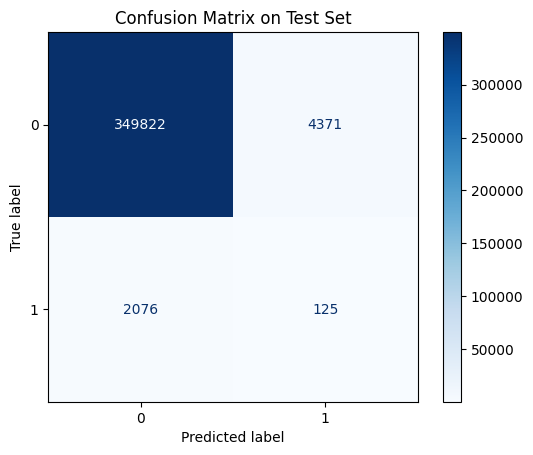

In [13]:
# Compute confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()
